In [15]:
import numpy as np 
import torch 
from torch.utils.data import DataLoader
import os
from torchvision import models
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve
import sys
sys.path.append('..')
from src.datasets import NIHChestXrayDataset

In [3]:
data_dir = "/mnt/n4i_ds423/Employee_Folder/Jalil_Ahmed/NIH_Chest_Xray_Dataset/datasets/nih-chest-xrays/data/versions/3"
df = pd.read_csv(os.path.join(data_dir, "df_test.csv"))

In [4]:
df['Image Path'] = df['Image Path'].replace(to_replace="/usr/app/data", value= data_dir, regex=True)

In [22]:
class_names = df["finding_labels"].str.get_dummies(sep="|").columns.tolist()

In [18]:
dataset = NIHChestXrayDataset(df, transform=None)

In [ ]:
dl = DataLoader(dataset,batch_size=64, shuffle=False, pin_memory=True)


In [5]:
model = models.resnet50(pretrained=False)
num_ftrs = model.fc.in_features
model.fc = torch.nn.Linear(num_ftrs, 15)
model.load_state_dict(torch.load('../results/Tutorial_27122025_00/checkpoint_max_metric.pt'))

/home/jahmed/miniconda3/envs/trackr/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jahmed/miniconda3/envs/trackr/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


<All keys matched successfully>

In [6]:
device = 'cpu'

In [10]:
model.eval()

all_probs = []
all_targets = []

with torch.no_grad():
    for x, y in dl:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)                 # (N, C)
        probs = torch.sigmoid(logits)     # (N, C)

        all_probs.append(probs.cpu())
        all_targets.append(y.cpu())

all_probs = torch.cat(all_probs).numpy()      # (N, C)
all_targets = torch.cat(all_targets).numpy()  # (N, C)


In [11]:
num_classes = all_targets.shape[1]

auc_per_class = []
for c in range(num_classes):
    # Skip classes with no positives or no negatives
    if len(np.unique(all_targets[:, c])) < 2:
        auc_per_class.append(np.nan)
        continue

    auc = roc_auc_score(all_targets[:, c], all_probs[:, c])
    auc_per_class.append(auc)

macro_auc = np.nanmean(auc_per_class)

print("Macro AUC:", macro_auc)
for i, auc in enumerate(auc_per_class):
    print(f"Class {i} AUC:", auc)

Macro AUC: 0.7446089530443137
Class 0 AUC: 0.7283921289788713
Class 1 AUC: 0.8522968120926507
Class 2 AUC: 0.7104362199468682
Class 3 AUC: 0.8252967539303723
Class 4 AUC: 0.7681774527760936
Class 5 AUC: 0.7840646246838195
Class 6 AUC: 0.7696757936361099
Class 7 AUC: 0.7858067515702916
Class 8 AUC: 0.6842031362691471
Class 9 AUC: 0.7061155625598279
Class 10 AUC: 0.7186308564160999
Class 11 AUC: 0.6423078294155067
Class 12 AUC: 0.7093366104969917
Class 13 AUC: 0.6683813320928452
Class 14 AUC: 0.8160124307992089


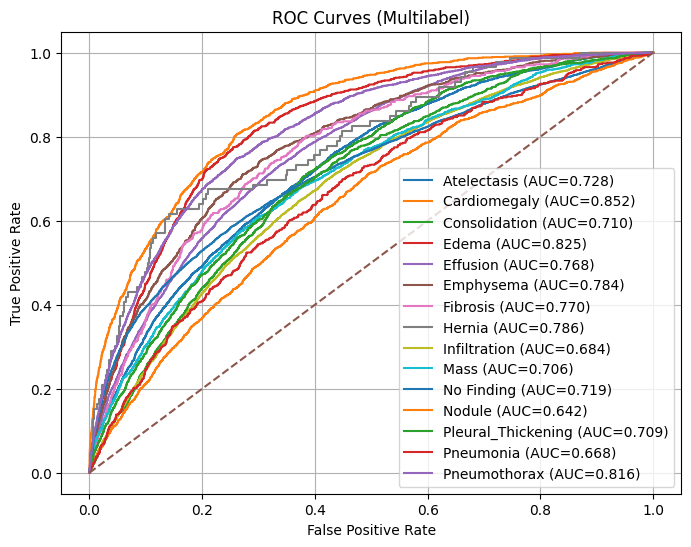

In [23]:
plt.figure(figsize=(8, 6))

for c in range(num_classes):
    if len(np.unique(all_targets[:, c])) < 2:
        continue

    fpr, tpr, _ = roc_curve(all_targets[:, c], all_probs[:, c])
    plt.plot(fpr, tpr, label=f"{class_names[c]} (AUC={auc_per_class[c]:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Multilabel)")
plt.legend()
plt.grid(True)
plt.show()
